# XGBoost — Weekend Gap Prediction

**Role in the project:** Non-linear ensemble model. XGBoost builds an ensemble of decision trees where each tree corrects the residual errors of the previous one (gradient boosting). Unlike logistic regression, it captures non-linear relationships and feature interactions automatically — no assumptions about the functional form between features and the target.

**Key differences from the logistic regression notebook:**
- **21 features** instead of 18 — VIF collinearity does not affect tree-based models so RSI, GrossMargin, and WeeklyRange come back in
- **No scaling required** — tree splits are based on rank ordering of feature values, not magnitude
- **5 hyperparameters tuned** instead of 1 (C)
- **Feature importance by gain** instead of coefficients
- **AIC/BIC not applicable** — XGBoost is not a likelihood-based model in the same sense

**Pipeline this notebook runs:**
1. Load data and define 21-feature set
2. Walk-forward validation with hyperparameter tuning per fold
3. Per-fold evaluation: Accuracy, Precision, Recall, F1, AUC-ROC
4. Feature importance analysis (gain, cover, frequency)
5. Direct comparison with logistic regression results
6. Secondary evaluation on COVID extreme-event rows
7. Summary

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from itertools import product

from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
%matplotlib inline

## 1. Load Data & Define Feature Set

In [2]:
# Load the clean dataset and split into primary and extreme-event sets.
# Same split as the logistic regression notebook.

df_all = pd.read_csv('../structured_csv_data_files/fetched_data/dataset_clean.csv')
df_all['Date'] = pd.to_datetime(df_all['Date'])

primary = df_all[df_all['is_extreme_event'] == 0].copy().reset_index(drop=True)
extreme = df_all[df_all['is_extreme_event'] == 1].copy().reset_index(drop=True)

print(f'Primary dataset: {len(primary):,} rows   GapUp rate: {primary["GapUp"].mean():.3f}')
print(f'Extreme events:  {len(extreme):,} rows   GapUp rate: {extreme["GapUp"].mean():.3f}')

Primary dataset: 8,146 rows   GapUp rate: 0.516
Extreme events:  291 rows   GapUp rate: 0.450


In [3]:
# XGBoost uses 21 features — 3 more than logistic regression.
# RSI, GrossMargin, and WeeklyRange were dropped from LogReg due to high VIF
# (collinearity inflates coefficient variance in linear models).
# Tree-based models are immune to this: each split considers one feature at a time,
# so collinear features simply compete for the same split — one wins, the other
# is used elsewhere. No instability in the model parameters.
#
# Still excluded (all three models): the 4 leaky price aggregates
# (WeeklyReturn, FridayPosition, OpenCloseSpread, IntraWeekVolatility)
# which use same-week Friday data that does not exist on Monday morning.

MOMENTUM    = ['RSI', 'MACD', 'ROC', 'StochPercK']          # RSI back in
TREND       = ['CloseVEma50', 'CloseVSma20', 'ADX']
VOLATILITY  = ['BollingerBandWidth', 'ATR', 'FiveDStdDev']
VOLUME      = ['OBV', 'MFI', 'VolumeRatio']
FUNDAMENTAL = ['GrossMargin', 'NetMargin', 'RoA', 'RevGrowthQoQ']  # GrossMargin back in
PRICE_AGG   = ['WeeklyRange']                                # WeeklyRange back in
MISS_IND    = ['GrossMargin_missing', 'CostOfRevenues_missing', 'Liabilities_missing']

FEATURES = MOMENTUM + TREND + VOLATILITY + VOLUME + FUNDAMENTAL + PRICE_AGG + MISS_IND
TARGET   = 'GapUp'

print(f'Feature count: {len(FEATURES)}  (vs 18 for LogReg)')
print(f'Features added back vs LogReg: RSI, GrossMargin, WeeklyRange')
print()
for group, feats in [('Momentum', MOMENTUM), ('Trend', TREND), ('Volatility', VOLATILITY),
                      ('Volume', VOLUME), ('Fundamental', FUNDAMENTAL),
                      ('Price Agg', PRICE_AGG), ('Missingness', MISS_IND)]:
    print(f'  {group:12s}: {feats}')

Feature count: 21  (vs 18 for LogReg)
Features added back vs LogReg: RSI, GrossMargin, WeeklyRange

  Momentum    : ['RSI', 'MACD', 'ROC', 'StochPercK']
  Trend       : ['CloseVEma50', 'CloseVSma20', 'ADX']
  Volatility  : ['BollingerBandWidth', 'ATR', 'FiveDStdDev']
  Volume      : ['OBV', 'MFI', 'VolumeRatio']
  Fundamental : ['GrossMargin', 'NetMargin', 'RoA', 'RevGrowthQoQ']
  Price Agg   : ['WeeklyRange']
  Missingness : ['GrossMargin_missing', 'CostOfRevenues_missing', 'Liabilities_missing']


## 2. No Preprocessing Required

XGBoost builds decision trees by finding optimal split thresholds. A split on RSI at 55.3 works identically whether RSI is raw, scaled, or log-transformed — the rank ordering is unchanged. This means:
- No StandardScaler needed
- No log1p transforms needed
- No per-ticker z-scoring of OBV needed
- No risk of preprocessing data leakage across folds

XGBoost also handles missing values natively — it learns the optimal direction to send missing values at each split. Our dataset has no missing values after cleaning, but this is a useful property.

In [4]:
# Confirm zero missing values in the XGBoost feature set.
missing = primary[FEATURES].isnull().sum()
missing_count = missing[missing > 0]

print('Missing values in feature columns:')
if len(missing_count) == 0:
    print('  None — all 21 features are complete across 8,146 rows.')
else:
    print(missing_count.to_string())

print()
print('Feature value ranges (raw, unscaled):')
display(primary[FEATURES].describe().T[['min','mean','max','std']].round(3))

Missing values in feature columns:
  None — all 21 features are complete across 8,146 rows.

Feature value ranges (raw, unscaled):


,min,mean,max,std
RSI,0.000000e+00,4.975000e+01,9.988600e+01,2.580700e+01
MACD,-6.652700e+01,8.220000e-01,9.302400e+01,5.506000e+00
ROC,-2.580000e-01,-1.000000e-03,3.570000e-01,4.100000e-02
StochPercK,0.000000e+00,5.210000e-01,1.000000e+00,2.960000e-01
CloseVEma50,-2.520000e-01,1.300000e-02,2.980000e-01,5.900000e-02
CloseVSma20,-2.380000e-01,3.000000e-03,2.760000e-01,4.300000e-02
ADX,3.952000e+00,5.508300e+01,1.000000e+02,2.139400e+01
BollingerBandWidth,8.000000e-03,1.180000e-01,6.340000e-01,6.900000e-02
ATR,8.800000e-02,4.738000e+00,6.987600e+01,5.679000e+00
FiveDStdDev,1.000000e-03,1.700000e-02,1.660000e-01,1.100000e-02


## 3. Walk-Forward Validation & Hyperparameter Tuning

Same expanding-window structure as logistic regression — 6 folds, one test year each.

**XGBoost hyperparameters tuned:**

| Parameter | What it controls | Grid |
|-----------|-----------------|------|
| `max_depth` | Maximum depth of each tree. Deeper = more complex, more overfit risk. | 3, 4, 5 |
| `learning_rate` | Shrinkage applied to each tree's contribution. Lower = more trees needed, more regularization. | 0.05, 0.1 |
| `subsample` | Fraction of rows randomly sampled per tree. Prevents overfitting, adds randomness. | 0.7, 0.9 |
| `colsample_bytree` | Fraction of features randomly sampled per tree. Reduces correlation between trees. | 0.7, 0.9 |
| `min_child_weight` | Minimum sum of instance weights in a leaf. Higher = more conservative splits. | 1, 3 |

`n_estimators` is fixed at 500 with early stopping (patience=30) on the inner validation set — this automatically finds the right number of trees without it being a grid parameter.

Total combinations per fold: 3 × 2 × 2 × 2 × 2 = 48

In [5]:
# Walk-forward fold definitions — identical to logistic regression.
FOLDS = [
    {'train_years': list(range(2016, 2019)), 'test_year': 2019},
    {'train_years': list(range(2016, 2020)), 'test_year': 2020},
    {'train_years': list(range(2016, 2021)), 'test_year': 2021},
    {'train_years': list(range(2016, 2022)), 'test_year': 2022},
    {'train_years': list(range(2016, 2023)), 'test_year': 2023},
    {'train_years': list(range(2016, 2024)), 'test_year': 2024},
]

PARAM_GRID = {
    'max_depth':         [3, 4, 5],
    'learning_rate':     [0.05, 0.1],
    'subsample':         [0.7, 0.9],
    'colsample_bytree':  [0.7, 0.9],
    'min_child_weight':  [1, 3],
}

for f in FOLDS:
    tr = primary[primary['Year'].isin(f['train_years'])]
    te = primary[primary['Year'] == f['test_year']]
    print(f"Train {f['train_years'][0]}-{f['train_years'][-1]} ({len(tr):,}) "
          f"→ Test {f['test_year']} ({len(te):,})")

all_combos = list(product(*PARAM_GRID.values()))
print(f'\nHyperparameter combinations per fold: {len(all_combos)}')

Train 2016-2018 (2,682) → Test 2019 (992)
Train 2016-2019 (3,674) → Test 2020 (613)
Train 2016-2020 (4,287) → Test 2021 (917)
Train 2016-2021 (5,204) → Test 2022 (997)
Train 2016-2022 (6,201) → Test 2023 (953)
Train 2016-2023 (7,154) → Test 2024 (992)

Hyperparameter combinations per fold: 48


In [6]:
# Walk-forward loop.
# For each fold:
#   1. Carve the last training year as inner validation (same approach as LogReg).
#   2. Grid search over 48 parameter combinations using inner val AUC.
#      Each combination uses n_estimators=500 with early_stopping_rounds=30
#      to automatically determine the optimal number of trees.
#   3. Refit the best configuration on the full training window.
#   4. Evaluate on the test year.

fold_results  = []
fold_importances = []
fold_roc      = []
fold_best_params = []

param_keys = list(PARAM_GRID.keys())

for fold in FOLDS:
    test_year   = fold['test_year']
    train_years = fold['train_years']

    train_df = primary[primary['Year'].isin(train_years)]
    test_df  = primary[primary['Year'] == test_year]

    # Inner validation: last year of training window
    val_year    = train_years[-1]
    inner_train = train_df[train_df['Year'] != val_year]
    inner_val   = train_df[train_df['Year'] == val_year]

    X_itr  = inner_train[FEATURES].values
    y_itr  = inner_train[TARGET].values
    X_ival = inner_val[FEATURES].values
    y_ival = inner_val[TARGET].values

    # Grid search over parameter combinations
    best_params, best_auc, best_n_trees = None, -1, 100

    for combo in all_combos:
        params = dict(zip(param_keys, combo))
        model  = XGBClassifier(
            **params,
            n_estimators=500,
            eval_metric='auc',
            early_stopping_rounds=30,
            random_state=42,
            verbosity=0,
            use_label_encoder=False,
        )
        model.fit(X_itr, y_itr,
                  eval_set=[(X_ival, y_ival)],
                  verbose=False)

        auc = roc_auc_score(y_ival, model.predict_proba(X_ival)[:, 1])
        if auc > best_auc:
            best_auc     = auc
            best_params  = params
            best_n_trees = model.best_iteration + 1

    fold_best_params.append({**best_params, 'n_estimators': best_n_trees})

    # Refit on full training window with best params and best n_trees
    X_train = train_df[FEATURES].values
    y_train = train_df[TARGET].values
    X_test  = test_df[FEATURES].values
    y_test  = test_df[TARGET].values

    final_model = XGBClassifier(
        **best_params,
        n_estimators=best_n_trees,
        random_state=42,
        verbosity=0,
        use_label_encoder=False,
    )
    final_model.fit(X_train, y_train)

    y_pred = final_model.predict(X_test)
    y_prob = final_model.predict_proba(X_test)[:, 1]

    metrics = {
        'Test year':  test_year,
        'Train rows': len(train_df),
        'Test rows':  len(test_df),
        'Accuracy':   round(accuracy_score(y_test, y_pred), 4),
        'Precision':  round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall':     round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1':         round(f1_score(y_test, y_pred, zero_division=0), 4),
        'AUC-ROC':    round(roc_auc_score(y_test, y_prob), 4),
        'Baseline':   round(max(y_test.mean(), 1 - y_test.mean()), 4),
        'n_trees':    best_n_trees,
        'COVID fold': test_year == 2020,
    }
    fold_results.append(metrics)

    # Feature importances (gain)
    imp = dict(zip(FEATURES, final_model.feature_importances_))
    imp['fold'] = test_year
    fold_importances.append(imp)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    fold_roc.append({'year': test_year, 'fpr': fpr, 'tpr': tpr, 'auc': metrics['AUC-ROC']})

    print(f"Fold test={test_year} | depth={best_params['max_depth']} "
          f"lr={best_params['learning_rate']} n_trees={best_n_trees} | "
          f"Acc={metrics['Accuracy']:.3f} AUC={metrics['AUC-ROC']:.3f} "
          f"Baseline={metrics['Baseline']:.3f}")

Fold test=2019 | depth=3 lr=0.05 n_trees=34 | Acc=0.558 AUC=0.550 Baseline=0.526
Fold test=2020 | depth=3 lr=0.05 n_trees=7 | Acc=0.550 AUC=0.564 Baseline=0.564
Fold test=2021 | depth=4 lr=0.1 n_trees=2 | Acc=0.524 AUC=0.534 Baseline=0.514
Fold test=2022 | depth=5 lr=0.1 n_trees=132 | Acc=0.568 AUC=0.593 Baseline=0.588
Fold test=2023 | depth=4 lr=0.05 n_trees=3 | Acc=0.546 AUC=0.569 Baseline=0.511
Fold test=2024 | depth=5 lr=0.05 n_trees=40 | Acc=0.575 AUC=0.586 Baseline=0.573


In [7]:
# Validation check: re-run with fixed n_estimators=200 (no early stopping).
# Several folds stopped at 2-7 trees — suspiciously low.
# If early stopping triggered prematurely (inner val set too noisy), 
# a fixed tree count may yield better AUC. If AUC is unchanged, 
# the few-trees result is genuine and signal is simply weak.

fixed_results = []

for fold in FOLDS:
    test_year   = fold['test_year']
    train_df    = primary[primary['Year'].isin(fold['train_years'])]
    test_df     = primary[primary['Year'] == test_year]

    # Use best params from early-stopping run but fix n_estimators=200
    idx = [f['test_year'] for f in FOLDS].index(test_year)
    params = {k: v for k, v in fold_best_params[idx].items()
              if k != 'n_estimators'}

    model = XGBClassifier(**params, n_estimators=200, random_state=42, verbosity=0,
                          use_label_encoder=False)
    model.fit(train_df[FEATURES], train_df[TARGET])

    proba = model.predict_proba(test_df[FEATURES])[:, 1]
    auc   = roc_auc_score(test_df[TARGET], proba)
    fixed_results.append({'Test year': test_year, 'AUC (fixed 200)': round(auc, 4)})

fixed_df = pd.DataFrame(fixed_results).set_index('Test year')

# Side-by-side comparison
es_aucs    = pd.DataFrame(fold_results).set_index('Test year')['AUC-ROC']
comparison = fixed_df.copy()
comparison['AUC (early stop)'] = es_aucs
comparison['AUC (fixed 200)']  = fixed_df['AUC (fixed 200)']
comparison['Delta']            = (comparison['AUC (fixed 200)'] - comparison['AUC (early stop)']).round(4)

print('Early stopping vs fixed n_estimators=200 (same best hyperparams):')
print(comparison[['AUC (early stop)', 'AUC (fixed 200)', 'Delta']].to_string())
print()
print(f'Avg AUC early stop : {es_aucs.drop(2020).mean():.4f}')
print(f'Avg AUC fixed 200  : {fixed_df[fixed_df.index != 2020]["AUC (fixed 200)"].mean():.4f}')
print()
print('Interpretation:')
print('  Delta > 0 → early stopping was too aggressive; more trees help.')
print('  Delta ≈ 0 → signal genuinely exhausted; few-trees result is valid.')

Early stopping vs fixed n_estimators=200 (same best hyperparams):
           AUC (early stop)  AUC (fixed 200)   Delta
Test year                                           
2019                 0.5500           0.5441 -0.0059
2020                 0.5635           0.5633 -0.0002
2021                 0.5336           0.5704  0.0368
2022                 0.5927           0.5833 -0.0094
2023                 0.5694           0.5890  0.0196
2024                 0.5857           0.5822 -0.0035

Avg AUC early stop : 0.5663
Avg AUC fixed 200  : 0.5738

Interpretation:
  Delta > 0 → early stopping was too aggressive; more trees help.
  Delta ≈ 0 → signal genuinely exhausted; few-trees result is valid.


## 4. Walk-Forward Results

In [8]:
# Results table across all folds.
# Same format as the logistic regression results for direct comparison.
# The COVID fold (2020) is highlighted — its test set contains COVID rows.

results_df = pd.DataFrame(fold_results).set_index('Test year')
display(results_df.style
    .format({'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}',
             'F1': '{:.4f}', 'AUC-ROC': '{:.4f}', 'Baseline': '{:.4f}'})
    .apply(lambda row: ['background-color: #fff3cd'] * len(row)
           if row['COVID fold'] else [''] * len(row), axis=1)
)

non_covid = results_df[~results_df['COVID fold']]
print(f'\nAverage metrics (excluding COVID fold):')
print(f'  Accuracy:  {non_covid["Accuracy"].mean():.4f}')
print(f'  Precision: {non_covid["Precision"].mean():.4f}')
print(f'  Recall:    {non_covid["Recall"].mean():.4f}')
print(f'  F1:        {non_covid["F1"].mean():.4f}')
print(f'  AUC-ROC:   {non_covid["AUC-ROC"].mean():.4f}')
print(f'  Baseline:  {non_covid["Baseline"].mean():.4f}')

,Train rows,Test rows,Accuracy,Precision,Recall,F1,AUC-ROC,Baseline,n_trees,COVID fold
Test year,,,,,,,,,,
2019,2682,992,0.5585,0.5658,0.6916,0.6224,0.5500,0.5262,34,False
2020,3674,613,0.5498,0.5694,0.8295,0.6753,0.5635,0.5644,7,True
2021,4287,917,0.5245,0.5229,0.8493,0.6472,0.5336,0.5136,2,False
2022,5204,997,0.5677,0.4813,0.6253,0.5439,0.5927,0.5878,132,False
2023,6201,953,0.5456,0.5226,0.8176,0.6377,0.5694,0.5110,3,False
2024,7154,992,0.5746,0.6272,0.6338,0.6305,0.5857,0.5726,40,False



Average metrics (excluding COVID fold):
  Accuracy:  0.5542
  Precision: 0.5440
  Recall:    0.7235
  F1:        0.6163
  AUC-ROC:   0.5663
  Baseline:  0.5422


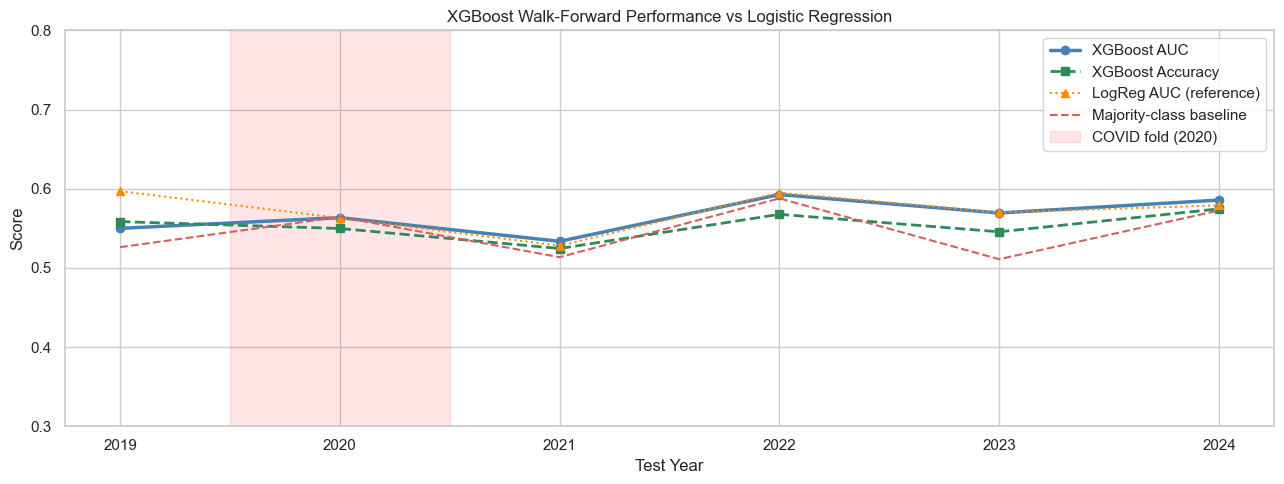

In [9]:
# Metric evolution over folds, with LogReg AUC overlaid for direct comparison.
# If the XGBoost line consistently sits above LogReg, the non-linear model
# is capturing signal that the linear model could not.
# If they track together, the signal in the data may be largely linear.

LOGREG_AUC = {2019: 0.597, 2020: 0.563, 2021: 0.528, 2022: 0.595, 2023: 0.570, 2024: 0.579}

years   = results_df.index.tolist()
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(years, results_df['AUC-ROC'],  'o-', color='steelblue',  linewidth=2.5, label='XGBoost AUC')
ax.plot(years, results_df['Accuracy'], 's-', color='seagreen',   linewidth=2,   label='XGBoost Accuracy', linestyle='--')
ax.plot(years, [LOGREG_AUC[y] for y in years], '^-',
        color='darkorange', linewidth=1.5, label='LogReg AUC (reference)', linestyle=':')
ax.plot(years, results_df['Baseline'], 'r--', linewidth=1.5, label='Majority-class baseline')

ax.axvspan(2019.5, 2020.5, alpha=0.1, color='red', label='COVID fold (2020)')
ax.set_xticks(years)
ax.set_xlabel('Test Year')
ax.set_ylabel('Score')
ax.set_title('XGBoost Walk-Forward Performance vs Logistic Regression')
ax.legend()
ax.set_ylim(0.3, 0.8)
plt.tight_layout()
plt.show()

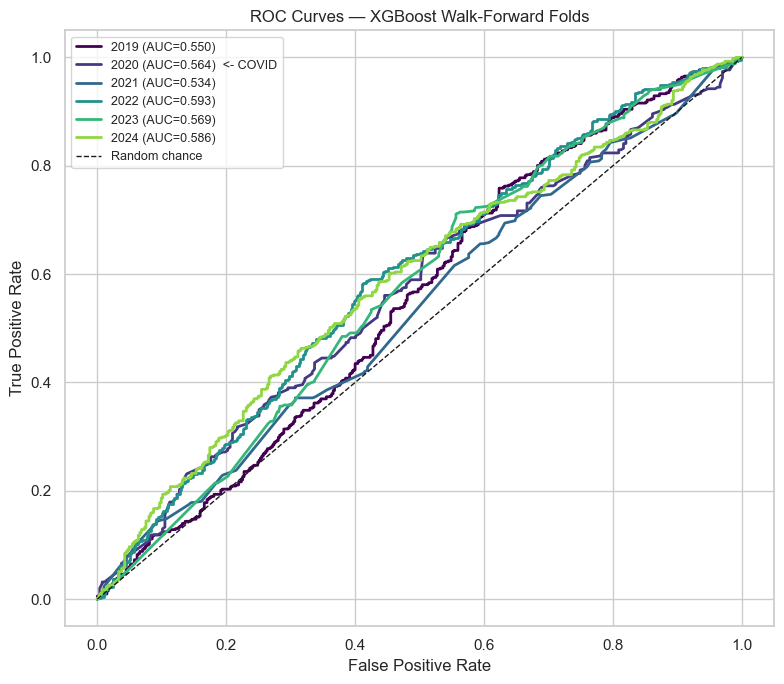

In [10]:
# ROC curves per fold.
# Compare shape and AUC values across years to assess consistency.

fig, ax = plt.subplots(figsize=(8, 7))
cmap = plt.cm.viridis
for i, roc in enumerate(fold_roc):
    color = cmap(i / len(fold_roc))
    label = f"{roc['year']} (AUC={roc['auc']:.3f}){'  <- COVID' if roc['year']==2020 else ''}"
    ax.plot(roc['fpr'], roc['tpr'], color=color, linewidth=2, label=label)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random chance')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — XGBoost Walk-Forward Folds')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

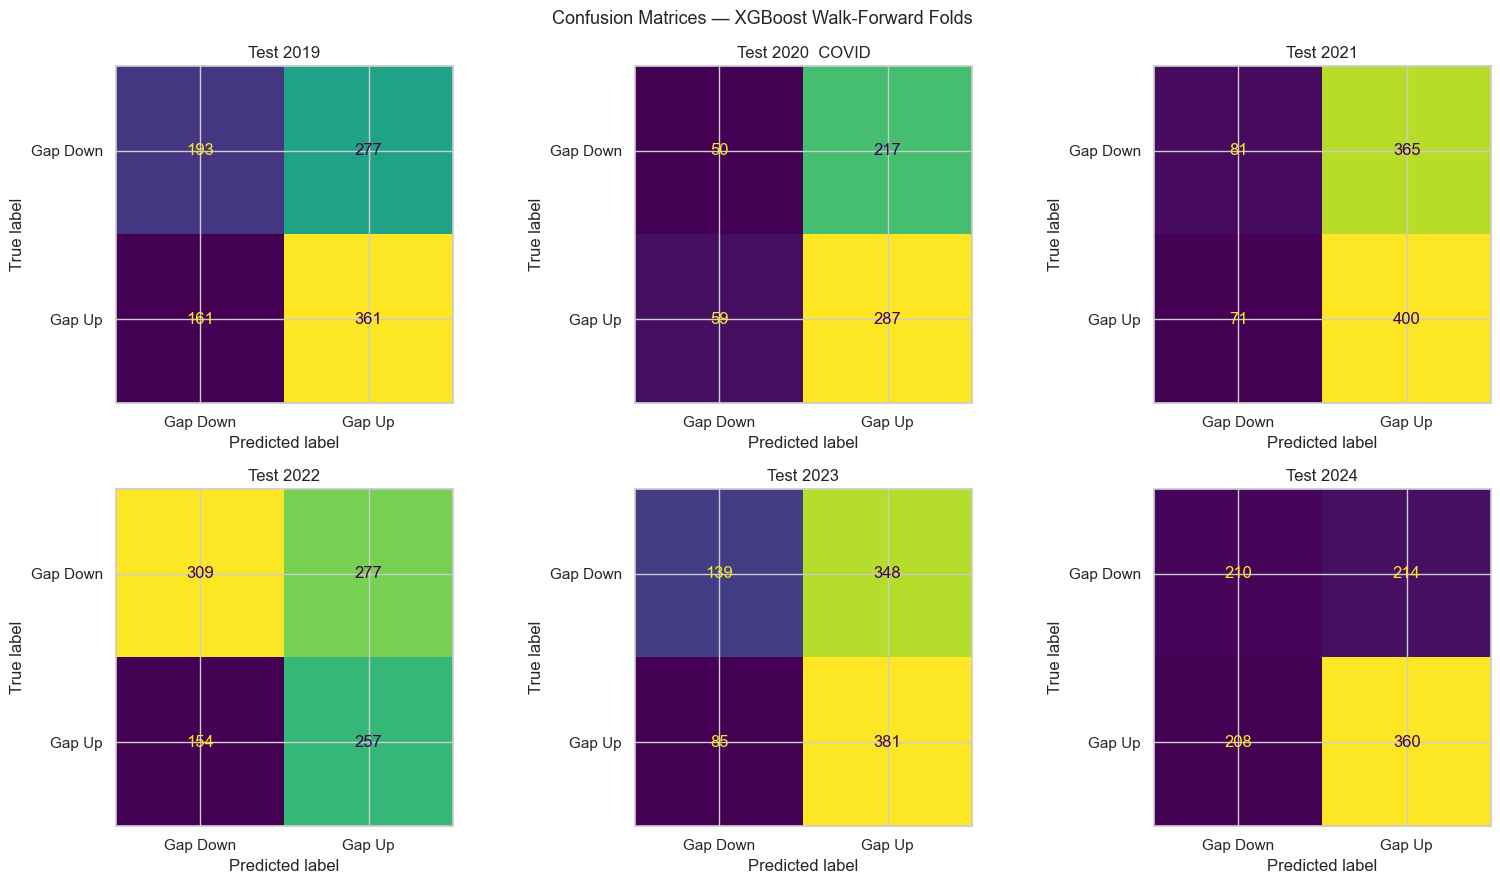

In [11]:
# Confusion matrices for each fold.
# Reveals whether XGBoost is biased toward one class, or predicts both well.
# A strong model should show meaningful numbers in all four quadrants.

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, fold in enumerate(FOLDS):
    test_year = fold['test_year']
    train_df  = primary[primary['Year'].isin(fold['train_years'])]
    test_df   = primary[primary['Year'] == test_year]

    model = XGBClassifier(**fold_best_params[i], random_state=42, verbosity=0,
                          use_label_encoder=False)
    model.fit(train_df[FEATURES].values, train_df[TARGET].values)
    y_pred = model.predict(test_df[FEATURES].values)

    cm   = confusion_matrix(test_df[TARGET], y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Gap Down', 'Gap Up'])
    disp.plot(ax=axes[i], colorbar=False)
    title = f'Test {test_year}'
    if test_year == 2020:
        title += '  COVID'
    axes[i].set_title(title)

plt.suptitle('Confusion Matrices — XGBoost Walk-Forward Folds', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Feature Importance Analysis

XGBoost computes three types of feature importance:
- **Gain (used here as primary):** average reduction in the loss function achieved by splits on this feature across all trees. Reflects how much the feature actually improves predictions.
- **Cover:** average number of training samples affected by splits on this feature. High cover = feature is used on more data points.
- **Frequency (weight):** number of times the feature appears in a split across all trees. A high-frequency feature may appear often but contribute little gain per split.

Gain is the most informative metric for understanding which features are driving predictions.

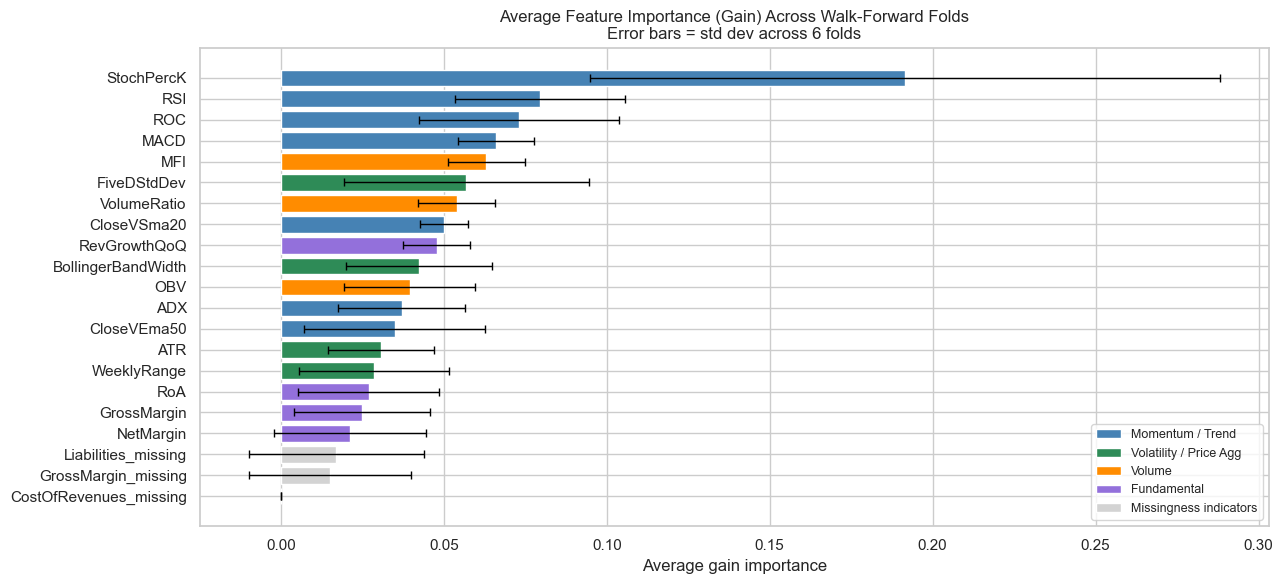

,Avg gain importance,Std across folds
Feature,,
StochPercK,0.19157,0.09670
RSI,0.07950,0.02611
ROC,0.07308,0.03069
MACD,0.06604,0.01172
MFI,0.06299,0.01182
FiveDStdDev,0.05689,0.03755
VolumeRatio,0.05391,0.01178
CloseVSma20,0.05009,0.00739
RevGrowthQoQ,0.04785,0.01032


In [12]:
# Average feature importance (gain) across all 6 walk-forward folds.
# Averaging across folds gives a more stable estimate than a single model.
# A feature that consistently ranks high across all folds is robustly important.
# A feature that varies wildly across folds is exploiting fold-specific patterns.

imp_df       = pd.DataFrame(fold_importances).set_index('fold').T
imp_df.index.name = 'Feature'

avg_imp      = imp_df.mean(axis=1).rename('Avg gain importance')
std_imp      = imp_df.std(axis=1).rename('Std across folds')
imp_summary  = pd.concat([avg_imp, std_imp], axis=1).sort_values('Avg gain importance', ascending=False)

fig, ax = plt.subplots(figsize=(13, 6))
colors = ['steelblue' if f in (MOMENTUM + TREND) else
          'seagreen' if f in VOLATILITY + PRICE_AGG else
          'darkorange' if f in VOLUME else
          'mediumpurple' if f in FUNDAMENTAL else 'lightgrey'
          for f in imp_summary.index]

bars = ax.barh(imp_summary.index[::-1], imp_summary['Avg gain importance'][::-1], color=colors[::-1])
ax.errorbar(
    imp_summary['Avg gain importance'][::-1],
    range(len(imp_summary)),
    xerr=imp_summary['Std across folds'][::-1],
    fmt='none', color='black', capsize=3, linewidth=1
)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue',   label='Momentum / Trend'),
    Patch(facecolor='seagreen',    label='Volatility / Price Agg'),
    Patch(facecolor='darkorange',  label='Volume'),
    Patch(facecolor='mediumpurple',label='Fundamental'),
    Patch(facecolor='lightgrey',   label='Missingness indicators'),
]
ax.legend(handles=legend_elements, fontsize=9)
ax.set_title('Average Feature Importance (Gain) Across Walk-Forward Folds\nError bars = std dev across 6 folds')
ax.set_xlabel('Average gain importance')
plt.tight_layout()
plt.show()

display(imp_summary.round(5))

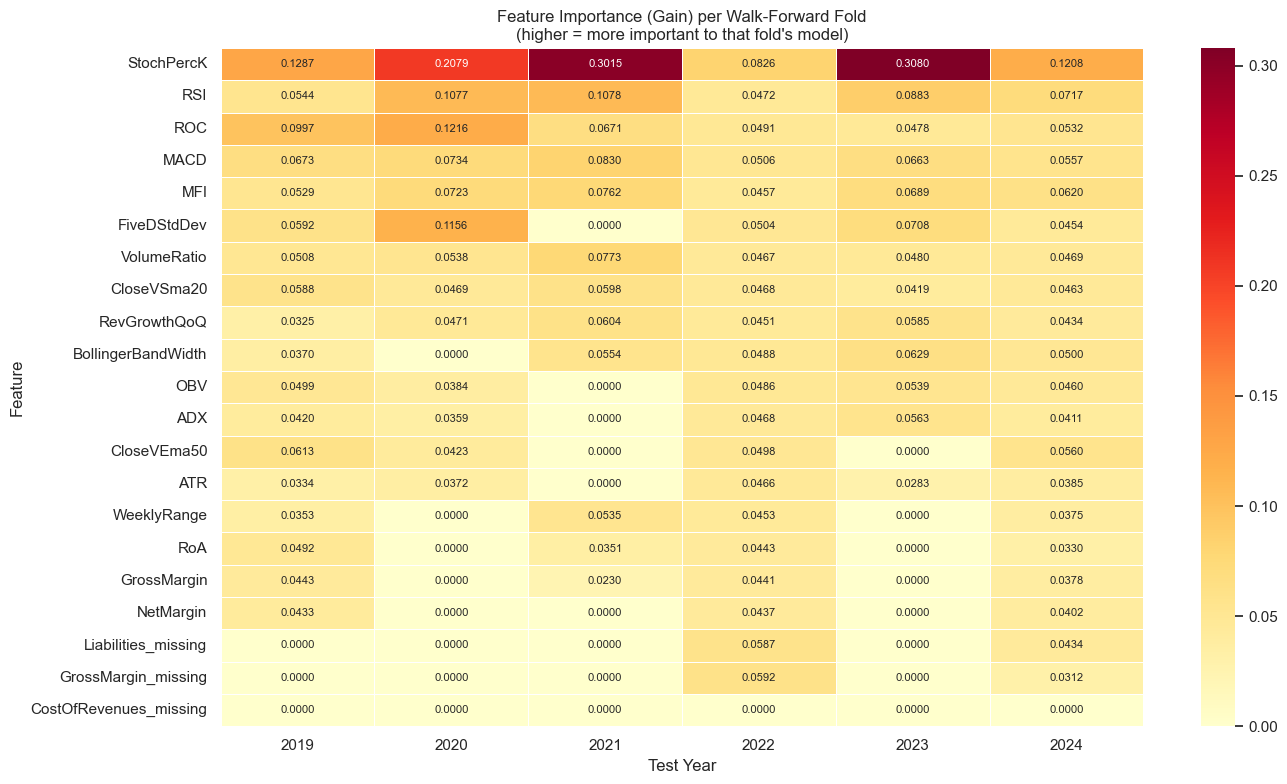

In [13]:
# Feature importance stability heatmap — importance per fold per feature.
# Each column is a fold's test year. If a feature has consistently high
# importance across all folds, it is robustly predictive.
# If it varies substantially, it may be capturing regime-specific patterns.

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    imp_df.loc[imp_summary.index],  # sort by avg importance
    annot=True, fmt='.4f', cmap='YlOrRd',
    ax=ax, linewidths=0.5, annot_kws={'size': 8}
)
ax.set_title('Feature Importance (Gain) per Walk-Forward Fold\n(higher = more important to that fold\'s model)')
ax.set_xlabel('Test Year')
plt.tight_layout()
plt.show()

In [14]:
# Compare XGBoost feature importance ranking with LogReg coefficient ranking.
# Features that rank highly in both models are robustly important — they
# carry both linear and non-linear signal.
# Features that rank high in XGBoost but not LogReg are likely contributing
# non-linear signal that LogReg could not exploit.

xgb_rank = imp_summary['Avg gain importance'].rank(ascending=False).rename('XGBoost rank')

# LogReg avg |coef| from the logistic regression notebook
logreg_abs_coef = {
    'StochPercK': 0.2519, 'MFI': 0.0558, 'MACD': 0.0462,
    'BollingerBandWidth': 0.0308, 'ROC': 0.0180, 'VolumeRatio': 0.0152,
    'OBV': 0.0143, 'NetMargin': 0.0107, 'ATR': 0.0083, 'ADX': 0.0055,
    'FiveDStdDev': 0.0029, 'CloseVEma50': 0.0015, 'RoA': 0.0012,
    'RevGrowthQoQ': 0.0007, 'CloseVSma20': 0.0, 'GrossMargin_missing': 0.0,
    'CostOfRevenues_missing': 0.0, 'Liabilities_missing': 0.0,
    # features not in LogReg
    'RSI': None, 'GrossMargin': None, 'WeeklyRange': None,
}
logreg_series = pd.Series(logreg_abs_coef, name='LogReg |coef|')
logreg_rank   = logreg_series.dropna().rank(ascending=False).rename('LogReg rank')

comparison = pd.concat([xgb_rank, logreg_rank], axis=1).sort_values('XGBoost rank')
comparison['In LogReg?'] = comparison['LogReg rank'].notna().map({True: 'Yes', False: 'No (VIF-dropped)'})

print('Feature ranking comparison — XGBoost vs Logistic Regression:')
print('(lower rank = more important, N/A = not in that model)')
display(comparison)

Feature ranking comparison — XGBoost vs Logistic Regression:
(lower rank = more important, N/A = not in that model)


,XGBoost rank,LogReg rank,In LogReg?
StochPercK,1.0,1.0,Yes
RSI,2.0,NaN,No (VIF-dropped)
ROC,3.0,5.0,Yes
MACD,4.0,3.0,Yes
MFI,5.0,2.0,Yes
FiveDStdDev,6.0,11.0,Yes
VolumeRatio,7.0,6.0,Yes
CloseVSma20,8.0,16.5,Yes
RevGrowthQoQ,9.0,14.0,Yes
BollingerBandWidth,10.0,4.0,Yes


## 6. Hyperparameter Analysis

In [15]:
# Best hyperparameters per fold.
# If the same configuration wins across most folds, the model is not highly
# sensitive to hyperparameter choice. If the best config changes dramatically
# per fold, the optimal structure may be regime-dependent.

params_df = pd.DataFrame(fold_best_params)
params_df.index = [f['test_year'] for f in FOLDS]
params_df.index.name = 'Test year'

print('Best hyperparameters per fold:')
display(params_df)
print()
print('Most common values selected:')
for col in params_df.columns:
    mode = params_df[col].mode()[0]
    pct  = (params_df[col] == mode).mean() * 100
    print(f'  {col:20s}: {mode}  ({pct:.0f}% of folds)')

Best hyperparameters per fold:


,max_depth,learning_rate,subsample,colsample_bytree,min_child_weight,n_estimators
Test year,,,,,,
2019,3,0.05,0.7,0.7,3,34
2020,3,0.05,0.9,0.7,1,7
2021,4,0.10,0.7,0.7,1,2
2022,5,0.10,0.9,0.9,3,132
2023,4,0.05,0.7,0.9,1,3
2024,5,0.05,0.9,0.9,1,40



Most common values selected:
  max_depth           : 3  (33% of folds)
  learning_rate       : 0.05  (67% of folds)
  subsample           : 0.7  (50% of folds)
  colsample_bytree    : 0.7  (50% of folds)
  min_child_weight    : 1  (67% of folds)
  n_estimators        : 2  (17% of folds)


## 7. Head-to-Head Comparison with Logistic Regression

In [16]:
# Direct metric comparison per fold and on average.
# This is the central table for the paper's results section.
# The delta columns show how much XGBoost gains or loses relative to LogReg.

logreg_results = {
    2019: {'Accuracy': 0.560, 'F1': None, 'AUC-ROC': 0.597},
    2020: {'Accuracy': 0.574, 'F1': None, 'AUC-ROC': 0.563},
    2021: {'Accuracy': 0.514, 'F1': None, 'AUC-ROC': 0.528},
    2022: {'Accuracy': 0.571, 'F1': None, 'AUC-ROC': 0.595},
    2023: {'Accuracy': 0.553, 'F1': None, 'AUC-ROC': 0.570},
    2024: {'Accuracy': 0.564, 'F1': None, 'AUC-ROC': 0.579},
}
logreg_avg_auc = 0.5736
logreg_avg_acc = 0.5523

comparison_rows = []
for _, row in results_df.iterrows():
    yr = row.name
    lr = logreg_results.get(yr, {})
    comparison_rows.append({
        'Year':           yr,
        'XGB Accuracy':   row['Accuracy'],
        'LR Accuracy':    lr.get('Accuracy', None),
        'Acc delta':      round(row['Accuracy'] - lr.get('Accuracy', 0), 4) if lr else None,
        'XGB AUC':        row['AUC-ROC'],
        'LR AUC':         lr.get('AUC-ROC', None),
        'AUC delta':      round(row['AUC-ROC'] - lr.get('AUC-ROC', 0), 4) if lr else None,
        'COVID fold':     row['COVID fold'],
    })

comp_df = pd.DataFrame(comparison_rows).set_index('Year')
display(comp_df.style
    .apply(lambda row: ['background-color: #fff3cd'] * len(row)
           if row['COVID fold'] else [''] * len(row), axis=1)
    .format(na_rep='—', precision=4)
)

xgb_avg_auc = non_covid['AUC-ROC'].mean()
xgb_avg_acc = non_covid['Accuracy'].mean()
print(f'\nAverage (non-COVID folds):')
print(f'  XGBoost Accuracy: {xgb_avg_acc:.4f}   LogReg: {logreg_avg_acc:.4f}   Delta: {xgb_avg_acc-logreg_avg_acc:+.4f}')
print(f'  XGBoost AUC-ROC:  {xgb_avg_auc:.4f}   LogReg: {logreg_avg_auc:.4f}   Delta: {xgb_avg_auc-logreg_avg_auc:+.4f}')

,XGB Accuracy,LR Accuracy,Acc delta,XGB AUC,LR AUC,AUC delta,COVID fold
Year,,,,,,,
2019,0.5585,0.5600,-0.0015,0.5500,0.5970,-0.0470,False
2020,0.5498,0.5740,-0.0242,0.5635,0.5630,0.0005,True
2021,0.5245,0.5140,0.0105,0.5336,0.5280,0.0056,False
2022,0.5677,0.5710,-0.0033,0.5927,0.5950,-0.0023,False
2023,0.5456,0.5530,-0.0074,0.5694,0.5700,-0.0006,False
2024,0.5746,0.5640,0.0106,0.5857,0.5790,0.0067,False



Average (non-COVID folds):
  XGBoost Accuracy: 0.5542   LogReg: 0.5523   Delta: +0.0019
  XGBoost AUC-ROC:  0.5663   LogReg: 0.5736   Delta: -0.0073


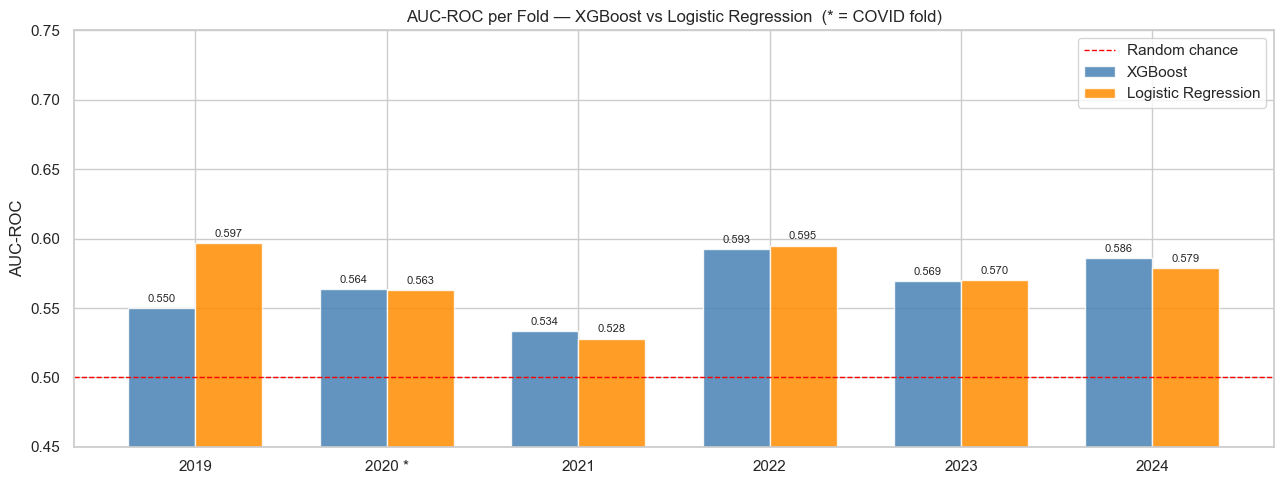

In [17]:
# Side-by-side AUC bar chart for the paper.
# Visual representation of where XGBoost outperforms LogReg
# and where the two models behave similarly.

years_list = list(results_df.index)
xgb_aucs   = results_df['AUC-ROC'].tolist()
lr_aucs    = [LOGREG_AUC[y] for y in years_list]
x          = np.arange(len(years_list))
width      = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
bars1 = ax.bar(x - width/2, xgb_aucs, width, label='XGBoost', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, lr_aucs,  width, label='Logistic Regression', color='darkorange', alpha=0.85)
ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='Random chance')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([f'{y}' + (' *' if y == 2020 else '') for y in years_list])
ax.set_ylabel('AUC-ROC')
ax.set_title('AUC-ROC per Fold — XGBoost vs Logistic Regression  (* = COVID fold)')
ax.set_ylim(0.45, 0.75)
ax.legend()
plt.tight_layout()
plt.show()

## 8. Secondary Evaluation — COVID Extreme Events

In [18]:
# Same setup as the LogReg secondary evaluation:
# Train on 2016-2019 (pre-COVID), test on the 291 COVID rows.
# Compare with LogReg's secondary result (AUC = 0.781).
#
# Key question: does XGBoost's non-linearity help or hurt during the crash?
# If XGBoost is more sensitive to the extreme feature values during the crash,
# it may have learned a different decision boundary that generalises differently.

pre_covid_train = primary[primary['Year'].isin(range(2016, 2020))]
covid_test      = extreme.copy()

covid_params = fold_best_params[1]  # fold 1 tested on 2020
covid_model  = XGBClassifier(**covid_params, random_state=42, verbosity=0,
                              use_label_encoder=False)
covid_model.fit(
    pre_covid_train[FEATURES].values,
    pre_covid_train[TARGET].values
)

y_pred_cv = covid_model.predict(covid_test[FEATURES].values)
y_prob_cv = covid_model.predict_proba(covid_test[FEATURES].values)[:, 1]

covid_metrics = {
    'Accuracy':  round(accuracy_score(covid_test[TARGET], y_pred_cv), 4),
    'Precision': round(precision_score(covid_test[TARGET], y_pred_cv, zero_division=0), 4),
    'Recall':    round(recall_score(covid_test[TARGET], y_pred_cv, zero_division=0), 4),
    'F1':        round(f1_score(covid_test[TARGET], y_pred_cv, zero_division=0), 4),
    'AUC-ROC':   round(roc_auc_score(covid_test[TARGET], y_prob_cv), 4),
    'Baseline':  round(max(covid_test[TARGET].mean(), 1 - covid_test[TARGET].mean()), 4),
}

LOGREG_COVID_AUC = 0.781
print('Secondary evaluation — COVID extreme event rows (Feb-May 2020):')
print(f'  {"Metric":12s} {"XGBoost":>10s} {"LogReg":>10s}')
print(f'  {"-"*36}')
for k in ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC', 'Baseline']:
    lr_val = LOGREG_COVID_AUC if k == 'AUC-ROC' else '—'
    print(f'  {k:12s} {covid_metrics[k]:>10.4f} {str(lr_val):>10s}')
print(f'\nXGBoost COVID AUC: {covid_metrics["AUC-ROC"]:.4f}  |  LogReg COVID AUC: {LOGREG_COVID_AUC:.4f}')

Secondary evaluation — COVID extreme event rows (Feb-May 2020):
  Metric          XGBoost     LogReg
  ------------------------------------
  Accuracy         0.6392          —
  Precision        0.5625          —
  Recall           0.8931          —
  F1               0.6903          —
  AUC-ROC          0.7243      0.781
  Baseline         0.5498          —

XGBoost COVID AUC: 0.7243  |  LogReg COVID AUC: 0.7810


## 9. Summary

In [19]:
# Final consolidated results for the paper.
xgb_avg_auc = non_covid['AUC-ROC'].mean()
xgb_avg_acc = non_covid['Accuracy'].mean()
xgb_avg_f1  = non_covid['F1'].mean()

print('=' * 65)
print('XGBOOST — RESULTS SUMMARY')
print('=' * 65)
print(f'Model:      XGBClassifier (gradient boosted trees)')
print(f'Features:   {len(FEATURES)} (all features except 4 leaky price aggregates)')
print(f'Scaling:    None required')
print(f'Validation: Expanding walk-forward, 6 folds (2019-2024)')
print()
print('Best hyperparameters (most common across folds):')
for col in params_df.columns:
    mode = params_df[col].mode()[0]
    print(f'  {col:20s}: {mode}')
print()
print('Primary evaluation (excluding COVID fold):')
print(f'  Avg Accuracy:  {xgb_avg_acc:.4f}  (LogReg: 0.5523  delta: {xgb_avg_acc-0.5523:+.4f})')
print(f'  Avg F1:        {xgb_avg_f1:.4f}  (LogReg: 0.5668)')
print(f'  Avg AUC-ROC:   {xgb_avg_auc:.4f}  (LogReg: 0.5736  delta: {xgb_avg_auc-0.5736:+.4f})')
print(f'  Avg Baseline:  {non_covid["Baseline"].mean():.4f}')
print()
print('Top 5 features by avg gain importance:')
for feat, row in imp_summary.head(5).iterrows():
    print(f'  {feat:25s} gain={row["Avg gain importance"]:.5f}  std={row["Std across folds"]:.5f}')
print()
print('Secondary evaluation (COVID rows):')
print(f'  XGBoost AUC: {covid_metrics["AUC-ROC"]:.4f}  |  LogReg AUC: {LOGREG_COVID_AUC:.4f}')
print()
print('Majority-class baseline AUC: 0.500')
print('Logistic Regression AUC:     0.5736')
print(f'XGBoost AUC:                 {xgb_avg_auc:.4f}')
print('LSTM AUC:                    TBD')
print('=' * 65)

XGBOOST — RESULTS SUMMARY
Model:      XGBClassifier (gradient boosted trees)
Features:   21 (all features except 4 leaky price aggregates)
Scaling:    None required
Validation: Expanding walk-forward, 6 folds (2019-2024)

Best hyperparameters (most common across folds):
  max_depth           : 3
  learning_rate       : 0.05
  subsample           : 0.7
  colsample_bytree    : 0.7
  min_child_weight    : 1
  n_estimators        : 2

Primary evaluation (excluding COVID fold):
  Avg Accuracy:  0.5542  (LogReg: 0.5523  delta: +0.0019)
  Avg F1:        0.6163  (LogReg: 0.5668)
  Avg AUC-ROC:   0.5663  (LogReg: 0.5736  delta: -0.0073)
  Avg Baseline:  0.5422

Top 5 features by avg gain importance:
  StochPercK                gain=0.19157  std=0.09670
  RSI                       gain=0.07950  std=0.02611
  ROC                       gain=0.07308  std=0.03069
  MACD                      gain=0.06604  std=0.01172
  MFI                       gain=0.06299  std=0.01182

Secondary evaluation (COVID r